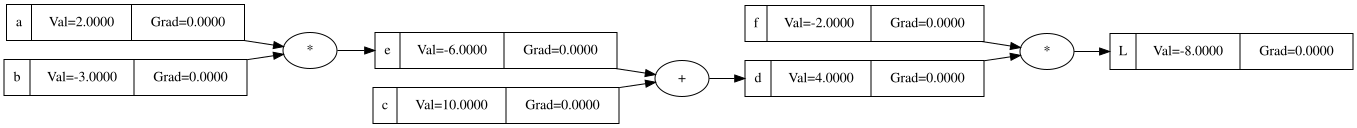

In [8]:
import graphviz

class Value:
    def __init__(self, data, preds=(), op='', label=''):
        self.data = data
        self.preds = set(preds)
        self.op = op
        self.label = label
        self.grad = 0.0

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        return Value(self.data + other.data, (self, other), '+')
    
    def __sub__(self, other):
        return Value(self.data - other.data, (self, other), '-')

    def __mul__(self, other):
        return Value(self.data * other.data, (self, other), '*')

    def __truediv__(self, other):
        return Value(self.data / other.data, (self, other), '/')    

def get_graph(root):
    g = graphviz.Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    
    nodes, edges = set(), set()
    def build_internal(n):
        if n not in nodes:
            nodes.add(n)
            for pred in n.preds:
                edges.add((pred, n))
                build_internal(pred)            
    build_internal(root)

    for n in nodes:
        node_id = str(id(n))
        g.node(node_id, label="{%s | Val=%.4f | Grad=%.4f}" % (n.label, n.data, n.grad), shape='record')
        if n.op:
            op_id = node_id + n.op
            g.node(op_id, label=n.op)
            g.edge(op_id, node_id)            
 
    for (n1, n2) in edges:
        pred_node_id = str(id(n1))
        op_id = str(id(n2)) + n2.op
        g.edge(pred_node_id, op_id)

    return g

a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
get_graph(L)
